Kelompok 5 AOL Introduction To Data Science
LA06

1. Angela Kei Budiwinoto (2702309920)
2. Leora Natania Klarise Purba (2702217195)
3. Zahra Annisa Afandi (2702284086)

Penjelasan data secara singkat:

Data ini diambil dari database sensus Amerika Serikat pada tahun 1994 yang berisi entri sebanyak 48,842.

data ini kami gunakan untuk memahami tren dan tren representasi demografi tertentu yang kemudian kami akan membuat model prediksi apakah seseorang menghasilkan lebih atau kurang dari USD 50.000 pada tahun 1994 sehingga diharapkan mampu memperoleh pemahaman tentang intuisi di balik angka-angka

### Data Cleaning

Data yang diambil telah dimodifikasi sedikit sehingga di dalamnya terdapat missing value, data tidak konsisten, dan data yang terduplikasi sehingga sebelum memvisualisasikan kita perlu untuk membersihkan data yang ada

In [1]:
import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pylab as plt

import seaborn as sns

In [2]:
income = pd.read_csv("train2.csv", sep = ",")
income.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income_>50K
0,67,...Private,366425,Doctorate,16,Divorced,Exec-managerial,Not-in-family,White,Male,NaN,NaN,60,United-States,1
1,17,Private,244602,12th,8,Never-married,Other-service,Own-child,White,M,NaN,NaN,15,United-States,0
2,31,Private,174201,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,NaN,NaN,40,United-States,1
3,58,State-gov_,110199,7th-8th,4,Married-civ-spouse,Transport-moving,Husband,White,Male,231.0,12.0,40,United-States,0
4,59,State-gov,105363,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Woman,0.0,15.0,40,United-States,0
5,59,State-gov,105363,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Woman,0.0,15.0,40,United-States,0
6,70,Private,216390,9th,5,Married-civ-spouse,Machine-op-inspct,Wife,White,F,2653.0,123.0,40,United-States,0
7,35,Self-emp-not-inc,361888,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0.0,0.0,60,Japan,0
8,28,Private,74784,HS-grad,9,Never-married,Handlers-cleaners,Not-in-family,White,Man,0.0,0.0,50,United-States,0
9,28,/Private,118089,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,4386.0,0.0,45,United-States,1


kita akan menampilkan 10 data teratas dan dapat kita lihat terdapat missing value di bagian capital gain dan loss kemudian data yang 'kembar' yaitu data di index ke 4 dan 5 kemudian dapat kita lihat data tidak konsisten terdapat pada gender dan juga workclass (untuk gender terdapat Male,M,dan Man untuk kategori Male dan Female, F, Woman untuk kategori Female. Sementara untuk workclass terdapat simbol2 yang mengganggu data aslinya)

In [3]:
income.tail(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income_>50K
43947,36,NaN,103886,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0.0,0.0,15,United-States,0
43948,44,Private,247880,Assoc-voc,11,Divorced,Exec-managerial,Not-in-family,White,Male,8614.0,0.0,40,United-States,1
43949,24,Private,137591,Some-college,10,Never-married,Sales,Own-child,White,Male,0.0,1762.0,40,United-States,0
43950,24,Private,41838,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,2407.0,0.0,40,United-States,0
43951,28,Private,64940,Some-college,10,Never-married,Other-service,Own-child,White,Female,134.0,12.0,30,United-States,0
43952,52,Private,68982,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,8765.0,100.0,50,United-States,1
43953,19,Private,116562,HS-grad,9,Never-married,Other-service,Own-child,White,Female,NaN,NaN,40,United-States,0
43954,30,Private,197947,Some-college,10,Divorced,Sales,Not-in-family,White,Male,2365.0,NaN,58,United-States,0
43955,46,Private,97883,Bachelors,13,Never-married,Sales,Not-in-family,White,Female,2345.0,124.0,35,United-States,0
43956,30,Private,375827,HS-grad,9,Never-married,Handlers-cleaners,Other-relative,White,Male,NaN,NaN,40,United-States,0


kita akan menampilkan 10 data terbawah dan dapat kita lihat terdapat missing value di bagian capital gain dan loss

Langkah pertama adalah remove data yang duplicates terlebih dahulu karena data tersebut dapat mempengaruhi

In [4]:
income = income.drop_duplicates()
income.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income_>50K
0,67,...Private,366425,Doctorate,16,Divorced,Exec-managerial,Not-in-family,White,Male,NaN,NaN,60,United-States,1
1,17,Private,244602,12th,8,Never-married,Other-service,Own-child,White,M,NaN,NaN,15,United-States,0
2,31,Private,174201,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,NaN,NaN,40,United-States,1
3,58,State-gov_,110199,7th-8th,4,Married-civ-spouse,Transport-moving,Husband,White,Male,231.0,12.0,40,United-States,0
4,59,State-gov,105363,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Woman,0.0,15.0,40,United-States,0
6,70,Private,216390,9th,5,Married-civ-spouse,Machine-op-inspct,Wife,White,F,2653.0,123.0,40,United-States,0
7,35,Self-emp-not-inc,361888,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0.0,0.0,60,Japan,0
8,28,Private,74784,HS-grad,9,Never-married,Handlers-cleaners,Not-in-family,White,Man,0.0,0.0,50,United-States,0
9,28,/Private,118089,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,4386.0,0.0,45,United-States,1
10,21,Private,138513,Some-college,10,Never-married,Exec-managerial,Own-child,White,Male,0.0,0.0,25,United-States,0


In [5]:
income.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43911 entries, 0 to 43956
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              43911 non-null  int64  
 1   workclass        41417 non-null  object 
 2   fnlwgt           43911 non-null  int64  
 3   education        43911 non-null  object 
 4   educational-num  43911 non-null  int64  
 5   marital-status   43911 non-null  object 
 6   occupation       41409 non-null  object 
 7   relationship     43911 non-null  object 
 8   race             43911 non-null  object 
 9   gender           43911 non-null  object 
 10  capital-gain     43906 non-null  float64
 11  capital-loss     43905 non-null  float64
 12  hours-per-week   43911 non-null  int64  
 13  native-country   43148 non-null  object 
 14  income_>50K      43911 non-null  int64  
dtypes: float64(2), int64(5), object(8)
memory usage: 5.4+ MB


untuk menjelaskan info mengenai data yang ada baik itu berapa jumlah kolom, berapa jumlah data yang di entri, tipe data dari masing2 variabel

In [6]:
pd.isna(income)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income_>50K
0,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43952,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
43953,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False
43954,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
43955,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


digunakan untuk mengetahui dimana nilai NaN atau missing values dari setiap kolom/variabelnya. ketika false maka data tersebut bukan missing values namun ketika true maka terdapat missing valuesnya

Atau untuk lebih jelasnya dapat kita cari di masing-masing variabel jumlah missing valuesnya 

In [7]:
pd.isna(income["age"]).sum()

0

In [8]:
pd.isna(income["workclass"]).sum()

2494

In [9]:
pd.isna(income["fnlwgt"]).sum()

0

In [10]:
pd.isna(income["education"]).sum()

0

In [11]:
pd.isna(income["educational-num"]).sum()

0

In [12]:
pd.isna(income["marital-status"]).sum()

0

In [13]:
pd.isna(income["occupation"]).sum()

2502

In [14]:
pd.isna(income["relationship"]).sum()

0

In [15]:
pd.isna(income["race"]).sum()

0

In [16]:
pd.isna(income["gender"]).sum()

0

In [17]:
pd.isna(income["capital-gain"]).sum()

5

In [18]:
pd.isna(income["capital-loss"]).sum()

6

In [19]:
pd.isna(income["hours-per-week"]).sum()

0

In [20]:
pd.isna(income["native-country"]).sum()

763

In [21]:
pd.isna(income["income_>50K"]).sum()

0

Dapat kita simpulkan bahwa variabel age, fnlwgt, education, educational-num, marital status, relationship, race, gender, hours per week serta income > 50K tidak memiliki missing value sementara untuk variabel native-country ada sebanyak 763 NaN, capital-gain sebanyak 5 NaN, capital-loss sebanyak 6 NaN, occupation sebanyak 2506 NaN, serta workclass sebanyak 2498 NaN

In [22]:
income = income.dropna()
income

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income_>50K
3,58,State-gov_,110199,7th-8th,4,Married-civ-spouse,Transport-moving,Husband,White,Male,231.0,12.0,40,United-States,0
4,59,State-gov,105363,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Woman,0.0,15.0,40,United-States,0
6,70,Private,216390,9th,5,Married-civ-spouse,Machine-op-inspct,Wife,White,F,2653.0,123.0,40,United-States,0
7,35,Self-emp-not-inc,361888,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0.0,0.0,60,Japan,0
8,28,Private,74784,HS-grad,9,Never-married,Handlers-cleaners,Not-in-family,White,Man,0.0,0.0,50,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43949,24,Private,137591,Some-college,10,Never-married,Sales,Own-child,White,Male,0.0,1762.0,40,United-States,0
43950,24,Private,41838,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,2407.0,0.0,40,United-States,0
43951,28,Private,64940,Some-college,10,Never-married,Other-service,Own-child,White,Female,134.0,12.0,30,United-States,0
43952,52,Private,68982,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,8765.0,100.0,50,United-States,1


Setelah kita mengetahui berapa banyak missing value dari tiap variabel maka yang diperlukan adalah membersihkan missing values tersebut dengan menghilangkan data yang terdapat missing valuesnya

Langkah selanjutnya adalah memilah dan memilih mana variabel yang nantinya akan kita visualisasikan sehingga kita akan menghilangkan variabel yang tidak diperlukan


variabel nya antara lain:
Native Country, fnlwgt, educational num dan race

In [23]:
income = income.drop(columns = "native-country")
income

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,income_>50K
3,58,State-gov_,110199,7th-8th,4,Married-civ-spouse,Transport-moving,Husband,White,Male,231.0,12.0,40,0
4,59,State-gov,105363,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Woman,0.0,15.0,40,0
6,70,Private,216390,9th,5,Married-civ-spouse,Machine-op-inspct,Wife,White,F,2653.0,123.0,40,0
7,35,Self-emp-not-inc,361888,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0.0,0.0,60,0
8,28,Private,74784,HS-grad,9,Never-married,Handlers-cleaners,Not-in-family,White,Man,0.0,0.0,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43949,24,Private,137591,Some-college,10,Never-married,Sales,Own-child,White,Male,0.0,1762.0,40,0
43950,24,Private,41838,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,2407.0,0.0,40,0
43951,28,Private,64940,Some-college,10,Never-married,Other-service,Own-child,White,Female,134.0,12.0,30,0
43952,52,Private,68982,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,8765.0,100.0,50,1


In [24]:
income = income.drop(columns = "fnlwgt")
income

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,income_>50K
3,58,State-gov_,7th-8th,4,Married-civ-spouse,Transport-moving,Husband,White,Male,231.0,12.0,40,0
4,59,State-gov,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Woman,0.0,15.0,40,0
6,70,Private,9th,5,Married-civ-spouse,Machine-op-inspct,Wife,White,F,2653.0,123.0,40,0
7,35,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0.0,0.0,60,0
8,28,Private,HS-grad,9,Never-married,Handlers-cleaners,Not-in-family,White,Man,0.0,0.0,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43949,24,Private,Some-college,10,Never-married,Sales,Own-child,White,Male,0.0,1762.0,40,0
43950,24,Private,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,2407.0,0.0,40,0
43951,28,Private,Some-college,10,Never-married,Other-service,Own-child,White,Female,134.0,12.0,30,0
43952,52,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,8765.0,100.0,50,1


In [25]:
income = income.drop(columns = "educational-num")
income

,age,workclass,education,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,income_>50K
3,58,State-gov_,7th-8th,Married-civ-spouse,Transport-moving,Husband,White,Male,231.0,12.0,40,0
4,59,State-gov,HS-grad,Never-married,Adm-clerical,Own-child,White,Woman,0.0,15.0,40,0
6,70,Private,9th,Married-civ-spouse,Machine-op-inspct,Wife,White,F,2653.0,123.0,40,0
7,35,Self-emp-not-inc,Bachelors,Married-civ-spouse,Sales,Husband,White,Male,0.0,0.0,60,0
8,28,Private,HS-grad,Never-married,Handlers-cleaners,Not-in-family,White,Man,0.0,0.0,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...
43949,24,Private,Some-college,Never-married,Sales,Own-child,White,Male,0.0,1762.0,40,0
43950,24,Private,Some-college,Married-civ-spouse,Craft-repair,Husband,White,Male,2407.0,0.0,40,0
43951,28,Private,Some-college,Never-married,Other-service,Own-child,White,Female,134.0,12.0,30,0
43952,52,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,8765.0,100.0,50,1


In [26]:
income = income.drop(columns = "race")
income

,age,workclass,education,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week,income_>50K
3,58,State-gov_,7th-8th,Married-civ-spouse,Transport-moving,Husband,Male,231.0,12.0,40,0
4,59,State-gov,HS-grad,Never-married,Adm-clerical,Own-child,Woman,0.0,15.0,40,0
6,70,Private,9th,Married-civ-spouse,Machine-op-inspct,Wife,F,2653.0,123.0,40,0
7,35,Self-emp-not-inc,Bachelors,Married-civ-spouse,Sales,Husband,Male,0.0,0.0,60,0
8,28,Private,HS-grad,Never-married,Handlers-cleaners,Not-in-family,Man,0.0,0.0,50,0
...,...,...,...,...,...,...,...,...,...,...,...
43949,24,Private,Some-college,Never-married,Sales,Own-child,Male,0.0,1762.0,40,0
43950,24,Private,Some-college,Married-civ-spouse,Craft-repair,Husband,Male,2407.0,0.0,40,0
43951,28,Private,Some-college,Never-married,Other-service,Own-child,Female,134.0,12.0,30,0
43952,52,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,Male,8765.0,100.0,50,1


kita akan menggunakan 11 variabel untuk nantinya divisualisasikan tapi dapat dilihat kalau masi ada data yang tidak konsisten yaitu gender dan juga workclass

In [27]:
income['gender'].value_counts()

gender
Male      27452
Female    13223
Woman         2
F             1
Man           1
Name: count, dtype: int64

Disini dapat kita lihat data yang tidak konsisten yang nantinya pasti akan mempengaruhi perhitungan sehingga kita perlu mereplace Man menjadi Male dan F serta Woman menjadi female

In [28]:
income = income.replace({'gender' : {'M': 'Male', 'Man': 'Male', 'F': 'Female', 'Woman': 'Female'}})
income

,age,workclass,education,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week,income_>50K
3,58,State-gov_,7th-8th,Married-civ-spouse,Transport-moving,Husband,Male,231.0,12.0,40,0
4,59,State-gov,HS-grad,Never-married,Adm-clerical,Own-child,Female,0.0,15.0,40,0
6,70,Private,9th,Married-civ-spouse,Machine-op-inspct,Wife,Female,2653.0,123.0,40,0
7,35,Self-emp-not-inc,Bachelors,Married-civ-spouse,Sales,Husband,Male,0.0,0.0,60,0
8,28,Private,HS-grad,Never-married,Handlers-cleaners,Not-in-family,Male,0.0,0.0,50,0
...,...,...,...,...,...,...,...,...,...,...,...
43949,24,Private,Some-college,Never-married,Sales,Own-child,Male,0.0,1762.0,40,0
43950,24,Private,Some-college,Married-civ-spouse,Craft-repair,Husband,Male,2407.0,0.0,40,0
43951,28,Private,Some-college,Never-married,Other-service,Own-child,Female,134.0,12.0,30,0
43952,52,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,Male,8765.0,100.0,50,1


In [29]:
income['workclass'].value_counts()

workclass
Private             30011
Self-emp-not-inc     3403
Local-gov            2792
State-gov            1719
Self-emp-inc         1470
Federal-gov          1262
Without-pay            20
State-gov_              1
/Private                1
Name: count, dtype: int64

Dapat kita lihat untuk state-gov dan private terdapat data yang tidak konsisten sehingga kita perlu mereplace state-gov_ menjadi state-gov dan /Private menjadi Private karena pasti mempengaruhi perhitungan nantinya

In [30]:
income = income.replace({'workclass' : {'State-gov_': 'State-gov', '/Private': 'Private'}})
income

,age,workclass,education,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week,income_>50K
3,58,State-gov,7th-8th,Married-civ-spouse,Transport-moving,Husband,Male,231.0,12.0,40,0
4,59,State-gov,HS-grad,Never-married,Adm-clerical,Own-child,Female,0.0,15.0,40,0
6,70,Private,9th,Married-civ-spouse,Machine-op-inspct,Wife,Female,2653.0,123.0,40,0
7,35,Self-emp-not-inc,Bachelors,Married-civ-spouse,Sales,Husband,Male,0.0,0.0,60,0
8,28,Private,HS-grad,Never-married,Handlers-cleaners,Not-in-family,Male,0.0,0.0,50,0
...,...,...,...,...,...,...,...,...,...,...,...
43949,24,Private,Some-college,Never-married,Sales,Own-child,Male,0.0,1762.0,40,0
43950,24,Private,Some-college,Married-civ-spouse,Craft-repair,Husband,Male,2407.0,0.0,40,0
43951,28,Private,Some-college,Never-married,Other-service,Own-child,Female,134.0,12.0,30,0
43952,52,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,Male,8765.0,100.0,50,1


In [31]:
income['income_>50K'].value_counts()

income_>50K
0    30594
1    10085
Name: count, dtype: int64

karena bentuknya masi dalam bilangan biner maka kita dapat ubah menjadi bentuk kategorik untuk 0 adalah no dan 1 adalah yes

In [32]:
income = income.replace({'income_>50K' : {0: 'No', 1: 'Yes'}})
income

,age,workclass,education,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week,income_>50K
3,58,State-gov,7th-8th,Married-civ-spouse,Transport-moving,Husband,Male,231.0,12.0,40,No
4,59,State-gov,HS-grad,Never-married,Adm-clerical,Own-child,Female,0.0,15.0,40,No
6,70,Private,9th,Married-civ-spouse,Machine-op-inspct,Wife,Female,2653.0,123.0,40,No
7,35,Self-emp-not-inc,Bachelors,Married-civ-spouse,Sales,Husband,Male,0.0,0.0,60,No
8,28,Private,HS-grad,Never-married,Handlers-cleaners,Not-in-family,Male,0.0,0.0,50,No
...,...,...,...,...,...,...,...,...,...,...,...
43949,24,Private,Some-college,Never-married,Sales,Own-child,Male,0.0,1762.0,40,No
43950,24,Private,Some-college,Married-civ-spouse,Craft-repair,Husband,Male,2407.0,0.0,40,No
43951,28,Private,Some-college,Never-married,Other-service,Own-child,Female,134.0,12.0,30,No
43952,52,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,Male,8765.0,100.0,50,Yes


In [33]:
def remove_outliers_iqr(data, column_name):
    Q1 = data[column_name].quantile(0.25)
    Q3 = data[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    # Menentukan batas bawah dan batas atas untuk outlier
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Menghapus outlier
    filtered_data = data[(data[column_name] >= lower_bound) & (data[column_name] <= upper_bound)]
    
    return filtered_data


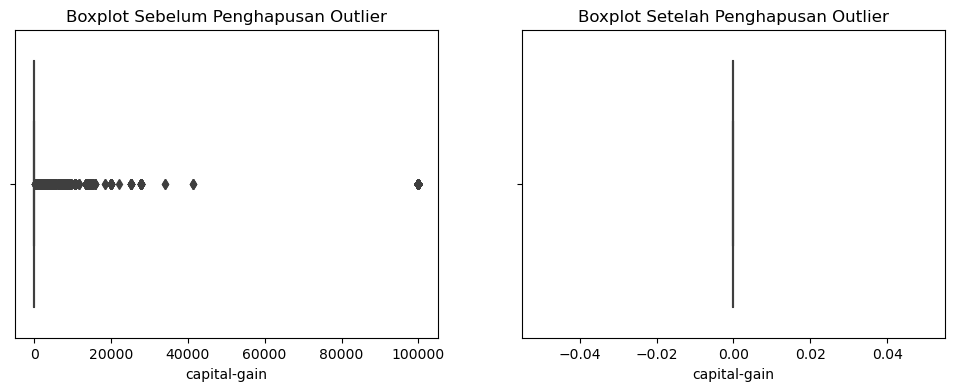

       age         workclass     education      marital-status  \
4       59         State-gov       HS-grad       Never-married   
7       35  Self-emp-not-inc     Bachelors  Married-civ-spouse   
8       28           Private       HS-grad       Never-married   
10      21           Private  Some-college       Never-married   
11      30  Self-emp-not-inc       HS-grad  Married-civ-spouse   
...    ...               ...           ...                 ...   
43941   33           Private  Some-college            Divorced   
43944   53           Private       HS-grad       Never-married   
43945   46           Private    Assoc-acdm             Widowed   
43946   47           Private     Bachelors  Married-civ-spouse   
43949   24           Private  Some-college       Never-married   

              occupation   relationship  gender  capital-gain  capital-loss  \
4           Adm-clerical      Own-child  Female           0.0          15.0   
7                  Sales        Husband    Male  

In [34]:
filtered_data = remove_outliers_iqr(income, 'capital-gain')

# Visualisasi boxplot sebelum dan sesudah penghapusan outlier
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=income['capital-gain'])
plt.title('Boxplot Sebelum Penghapusan Outlier')

plt.subplot(1, 2, 2)
sns.boxplot(x=filtered_data['capital-gain'])
plt.title('Boxplot Setelah Penghapusan Outlier')

plt.show()

# Menampilkan hasil penghapusan outlier
print(filtered_data)

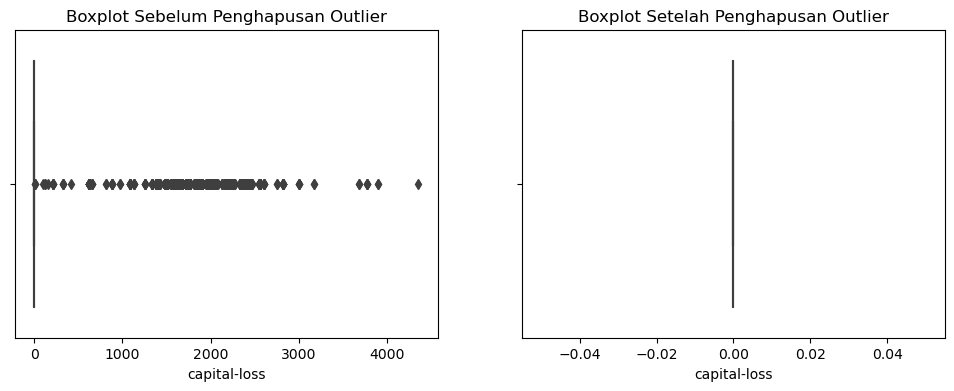

       age         workclass     education      marital-status  \
7       35  Self-emp-not-inc     Bachelors  Married-civ-spouse   
8       28           Private       HS-grad       Never-married   
9       28           Private       HS-grad  Married-civ-spouse   
10      21           Private  Some-college       Never-married   
11      30  Self-emp-not-inc       HS-grad  Married-civ-spouse   
...    ...               ...           ...                 ...   
43944   53           Private       HS-grad       Never-married   
43945   46           Private    Assoc-acdm             Widowed   
43946   47           Private     Bachelors  Married-civ-spouse   
43948   44           Private     Assoc-voc            Divorced   
43950   24           Private  Some-college  Married-civ-spouse   

              occupation   relationship  gender  capital-gain  capital-loss  \
7                  Sales        Husband    Male           0.0           0.0   
8      Handlers-cleaners  Not-in-family    Male  

In [35]:
filtered_data = remove_outliers_iqr(income, 'capital-loss')

# Visualisasi boxplot sebelum dan sesudah penghapusan outlier
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=income['capital-loss'])
plt.title('Boxplot Sebelum Penghapusan Outlier')

plt.subplot(1, 2, 2)
sns.boxplot(x=filtered_data['capital-loss'])
plt.title('Boxplot Setelah Penghapusan Outlier')

plt.show()

# Menampilkan hasil penghapusan outlier
print(filtered_data)

### Data Visualization

Setelah data dipastikan bersih dari beberapa hal yang mengganggu perhitungan (dalam hal ini missing values, data duplikat, dan data tidak konsisten) maka kita akan memvisualisasikan data tersebut lalu menginterpretasikannya

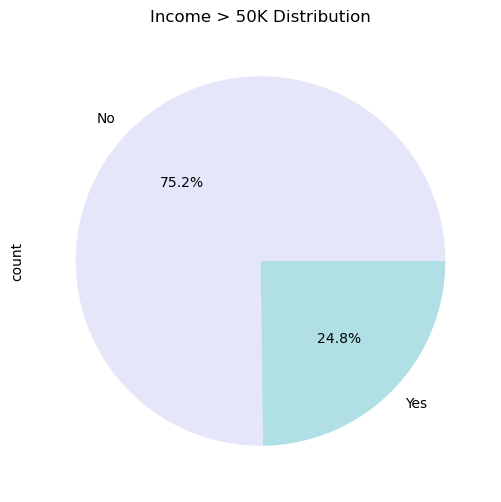

In [36]:
plt.figure(figsize=(6, 6))
income['income_>50K'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#E6E6FA', '#B0E0E6'])
plt.title('Income > 50K Distribution')
plt.show()

dataset ini mengandung distribusi dari 24,8% data dengan income diatas USD 50K dan 75,2% data dengan income dibawah USD 50 K.

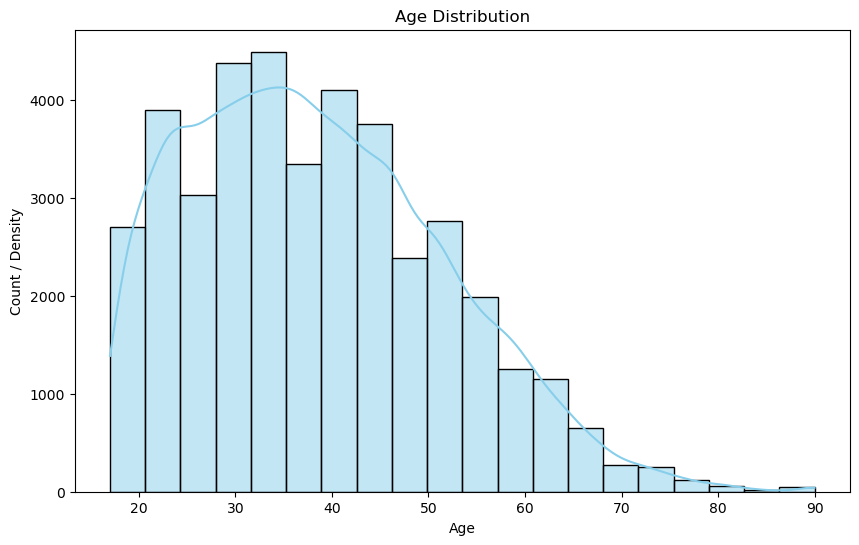

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(income['age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count / Density')
plt.show()

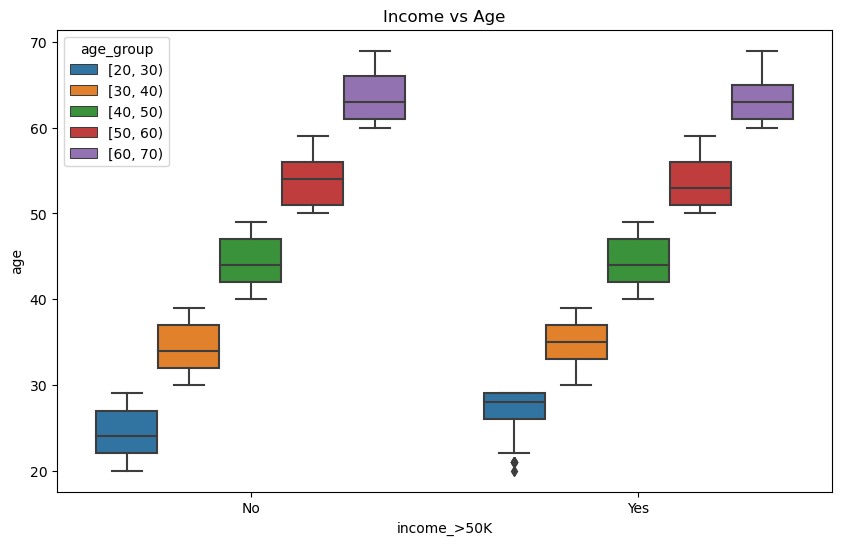

In [41]:
income['age_group'] = pd.cut(income['age'], bins=range(20, 80, 10), right=False)

# Mengatur ukuran figure
plt.figure(figsize=(10, 6))

# Membuat boxplot dengan seaborn
sns.boxplot(x='income_>50K', y='age', hue='age_group', data=income)

plt.title('Income vs Age')
# Menampilkan plot
plt.show()

Kolom 'age' menggambarkan usia individu. Gambar dari diagram 'age distribution' menunjukkan distribusi umur di antara entri dalam kumpulan data tersebut usianya tersebar mulai dari 17 hingga 90 tahun dengan mayoritas entri antara usia 25 sampai 50 tahun. karena banyak usia yang diwakili maka kami mengelompokkan entri ke dalam kelompok umur dengan interval masing-masing 10 tahun dengan menggunakan interval terbuka dan tertutup (lihat diagram income>=50K vs age) untuk menyajikan data secara lebih ringkas.

melihat grafik tersebut terlihat terdapat sejumlah besar varians antara rasio >50K hingga <=50K antar kelompok umur. rasio yang paling menarik untuk diperhatikan adalah rasio pada kelompok usia 20-30, 60-70, dan 70-80 dimana terdapat hampir tidak ada peluang untuk memiliki penghasilan diatas USD 50K. rasio entri untuk kelompok usia 30-40 dan 50-60 sangat bervariasi

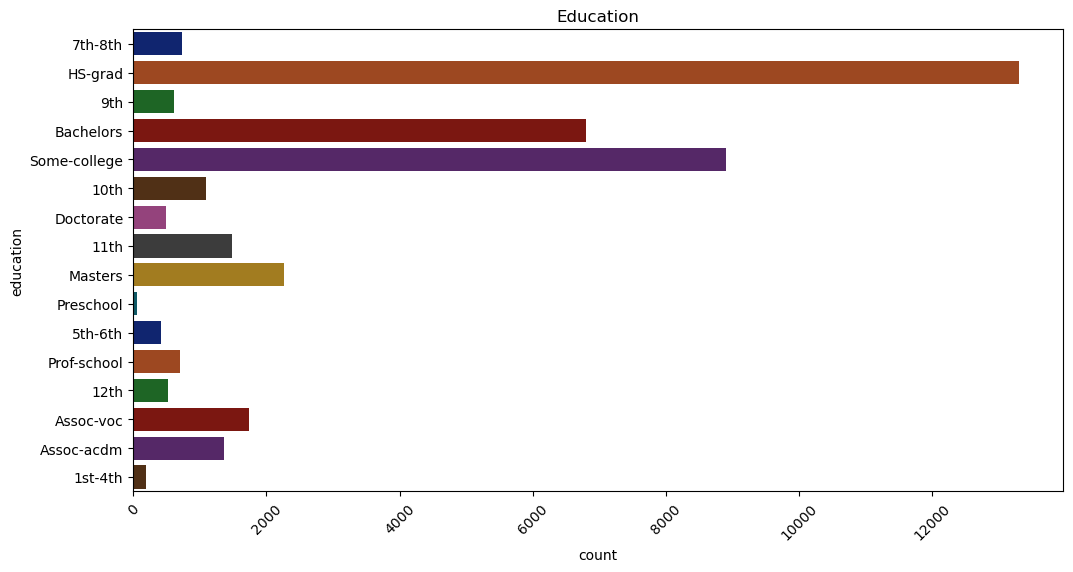

In [40]:
custom_palette = sns.color_palette("dark")

plt.figure(figsize=(12, 6))
sns.countplot(y='education', data=income, palette=custom_palette)
plt.title('Education')
plt.xticks(rotation=45)
plt.show()

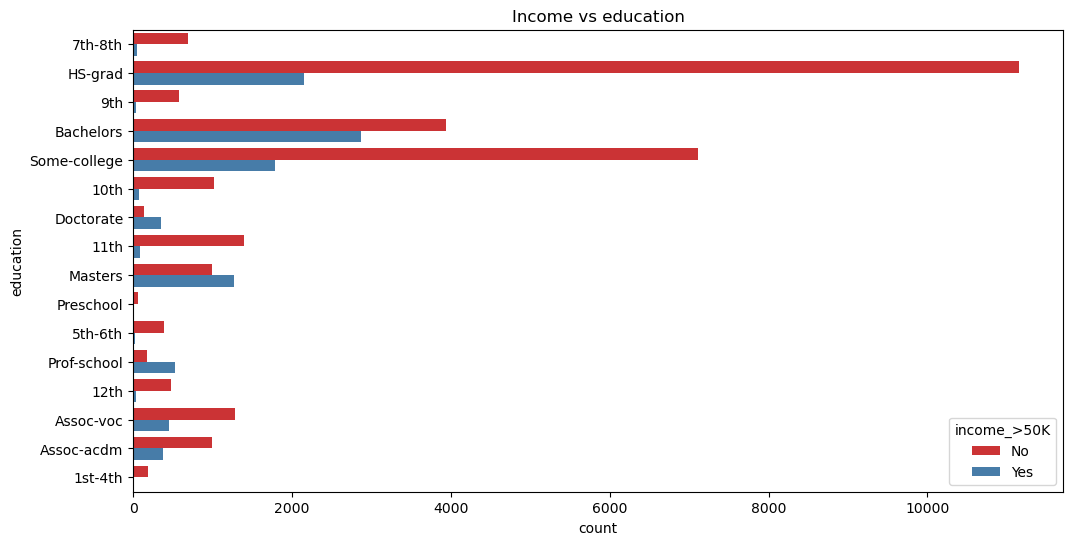

In [51]:
plt.figure(figsize=(12, 6))
sns.countplot(y='education', hue='income_>50K', data=income, palette='Set1', dodge=True)
plt.title('Income vs education')
plt.show()

kolom 'education' menggambarkan tingkat pendidikan tertinggi setiap individu. dari grafik 'education' menunjukkan distribusi berbagai tingkat pendidikan antar individu dalam kumpulan data. tingkat pendidikan mulai dari pra-sekolah sampai prof-school. Sebagian besar individu dalam kumpulan data paling banyak adalah lulusan pendidikan sekolah menengah atas, sementara hanya sebagian kecil yang merupakan tamatan preschool.

diagram 'income >=50 K vs education' menunjukkan hubungan tersebut antara tingkat pendidikan tertinggi dengan jumlah penduduk yang memiliki penghasilan diatas USD 50K atau dibawah USD 50K. Secara umum, tingkat pendidikan yang lebih tinggi berkorelasi dengan persentase yang lebih tinggi memiliki penghasilan di atas USD 50K. salah satu statistik yang menarik untuk diperhatikan adalah rasio individu yang memiliki penghasilan di atas USD 50K lebih banyak minimal menempuh pendidikan master, doctorate, bahkan profschool

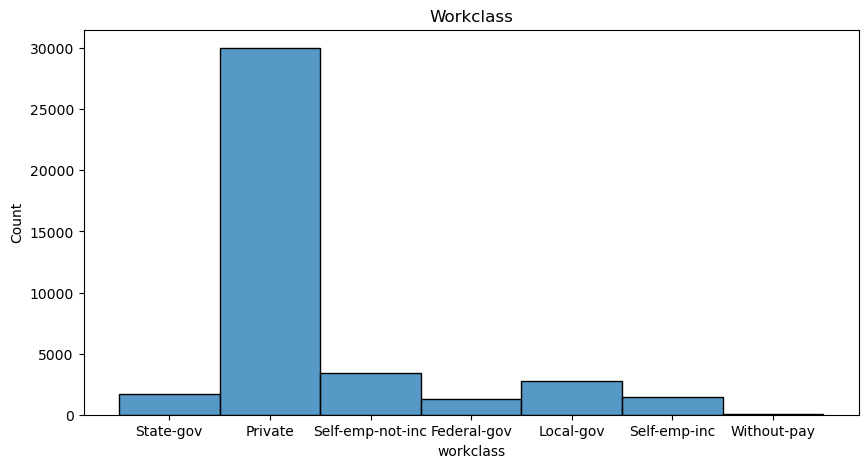

In [42]:
plt.figure(figsize=(10, 5))
sns.histplot(income['workclass'], bins=20, kde=False)
plt.title('Workclass')
plt.show()

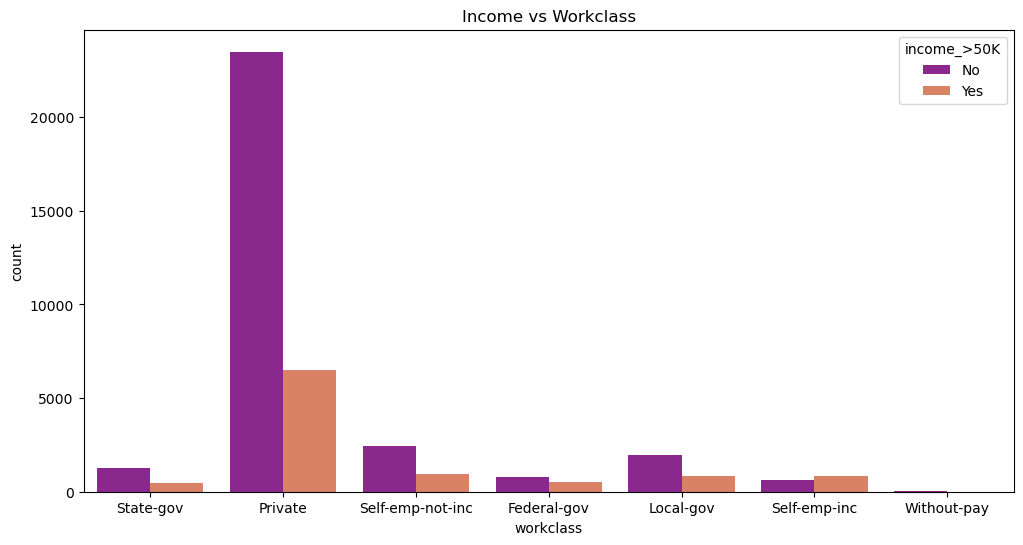

In [52]:
plt.figure(figsize=(12, 6))
sns.countplot(x='workclass', hue='income_>50K', data=income, palette='plasma', dodge=True)
plt.title('Income vs Workclass')
plt.show()

Dari diagram 'Workclass' di atas mayoritas penduduk bekerja di sektor swasta. Kemungkinan penghasilan di bawah USD 50K serupa di antara kelas pekerja kecuali untuk self-emp-inc(orang tersebut mempunyai perusahannya sendiri)

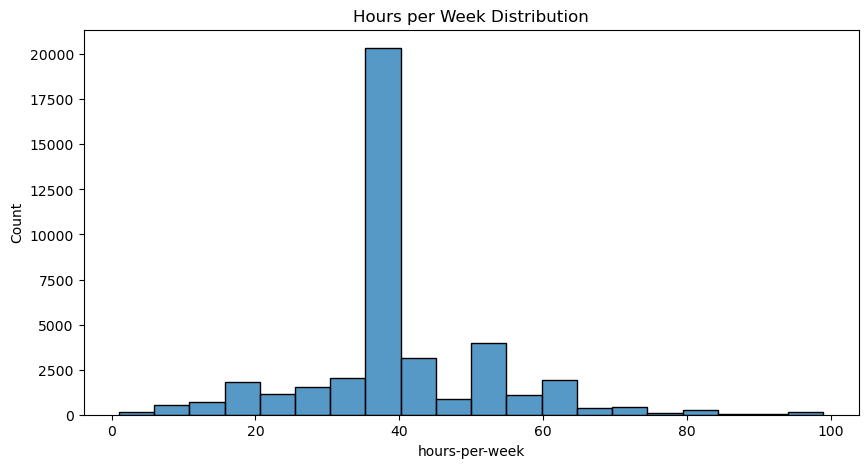

In [44]:
plt.figure(figsize=(10, 5))
sns.histplot(income['hours-per-week'], bins=20, kde=False)
plt.title('Hours per Week Distribution')
plt.show()

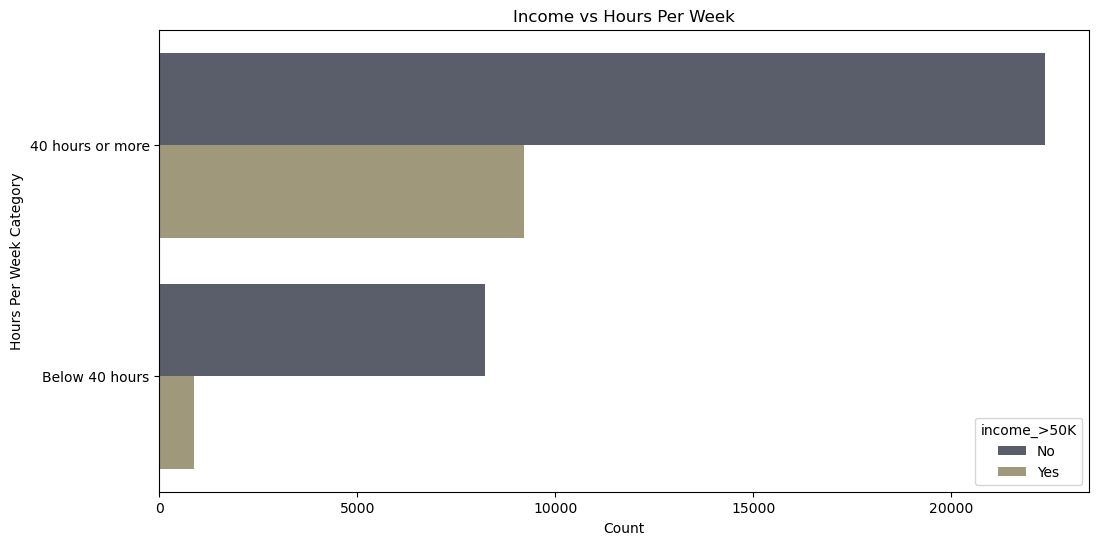

In [53]:
income['hours_category'] = np.where(income['hours-per-week'] < 40, 'Below 40 hours', '40 hours or more')

plt.figure(figsize=(12, 6))
sns.countplot(y='hours_category', hue='income_>50K', data=income, palette='cividis', dodge=True)
plt.title('Income vs Hours Per Week')
plt.xlabel('Count')
plt.ylabel('Hours Per Week Category')
plt.show()

Dari diagram 'Hours Per Week Distribution' di atas sebagian besar masyarakat bekerja hingga 40 jam per minggu. terlepas dari distribusi yang tidak seragam, diagram 'income >50K vs Hours Per Week' menunjukkan bahwa persentase individu baik yang bekerja di atas 40 jam maupun dibawah 40 jam memiliki penghasilan di bawah USD 50K

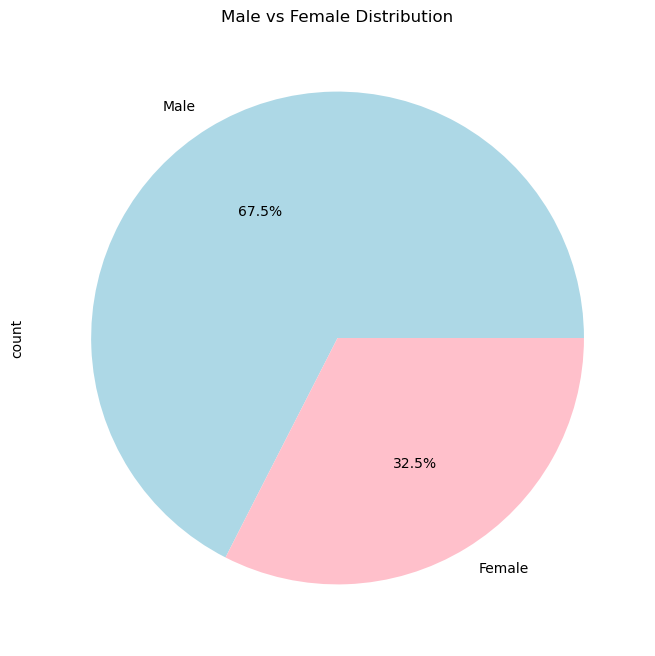

In [46]:
colors = ['#ADD8E6', '#FFC0CB']

plt.figure(figsize=(8, 8))
income['gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=colors)
plt.title('Male vs Female Distribution')
plt.show()

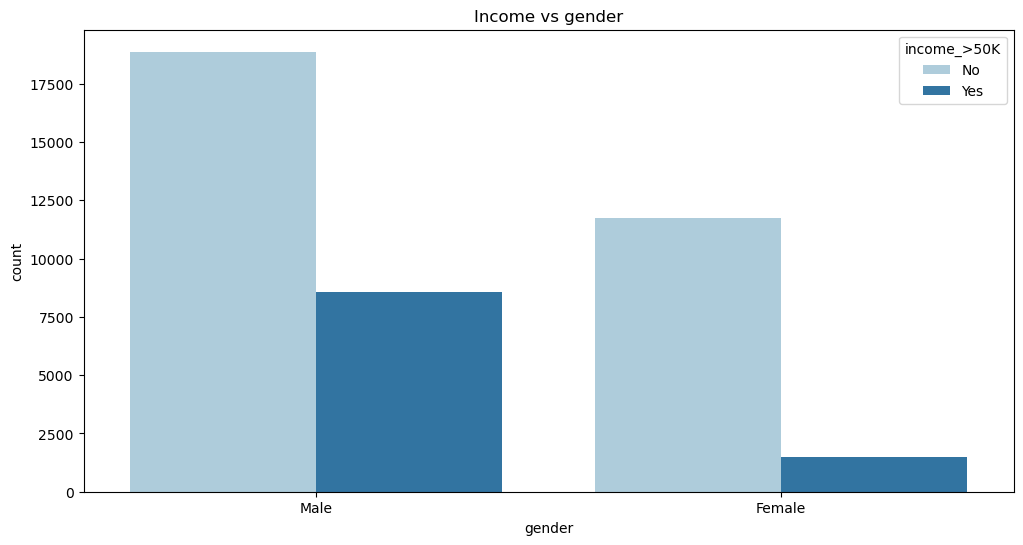

In [54]:
plt.figure(figsize=(12, 6))
sns.countplot(x='gender', hue='income_>50K', data=income, palette='Paired', dodge=True)
plt.title('Income vs gender')
plt.show()

Dari diagram 'Male vs Female Distribution' kita dapat melihat bahwa perbandingan jumlah sampel laki-laki dua kali lipat dari jumlah sampel perempuan dalam kumpulan data. Meskipun hal ini terlihat tidak begitu mempengaruhi prediksi kami, namun kita dapat melihat distribusi pendapatannya dari diagram 'Income >50K vs workclass' bahwa persentase laki-laki yang berpenghasilan diatas USD 50K jauh lebih besar dibandingkan persentase perempuan yang berpenghasilan sama. ini tentunya bisa menjadi faktor yang signifikan dan menjadi hal yang dipertimbangkan dalam prediksi kami.